# Ultimate Game Insights：深入数据分析

本 Notebook 延续 `01_initial_eda.ipynb` 的工作，对 Ultimate Games Dataset 进行更深入的探索分析。本部分重点关注游戏类型、平台、发行年份、评分、热度和玩家参与度之间的关系，并继续进行适合课程报告使用的可视化与特征工程。

本 Notebook 仍然属于探索性数据分析阶段，不训练复杂机器学习模型，不做推荐系统，也不做预测任务。

## 1. 数据读取与回顾

本节读取上一步处理后的数据，并快速回顾数据规模、字段情况和缺失值情况，为后续深入分析做准备。

读取逻辑为：优先读取 `data/processed/Ultimate_Games_Dataset_cleaned.csv`；如果该文件不存在，则回退读取 `data/raw/Ultimate_Games_Dataset.csv`。这样可以兼容后续已经保存清洗数据的情况，也可以在当前只有原始数据时直接运行。

In [1]:
# 基础依赖：只使用项目已经安装的常用数据分析包
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

# 图表风格保持简洁，图表文字尽量使用英文，避免中文字体问题
sns.set_theme(style="whitegrid", context="notebook")
plt.style.use("seaborn-v0_8-whitegrid")

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Ultimate_Games_Dataset.csv"
CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "Ultimate_Games_Dataset_cleaned.csv"
FEATURES_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "Ultimate_Games_Dataset_features.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if CLEANED_DATA_PATH.exists():
    data_path = CLEANED_DATA_PATH
    print(f"读取处理后的数据文件：{data_path}")
elif RAW_DATA_PATH.exists():
    data_path = RAW_DATA_PATH
    print(f"未找到 cleaned 数据，回退读取原始数据文件：{data_path}")
else:
    raise FileNotFoundError(
        "没有找到数据文件。请将 CSV 放到 data/raw/Ultimate_Games_Dataset.csv，"
        "或提供 data/processed/Ultimate_Games_Dataset_cleaned.csv。"
    )

df = pd.read_csv(data_path)
df_features = df.copy()

display(df.head())
print(f"数据维度：{df.shape[0]:,} 行 x {df.shape[1]:,} 列")
print(f"字段数量：{len(df.columns):,}")

missing_top10 = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_ratio": (df.isna().mean() * 100).round(2),
    })
    .sort_values("missing_count", ascending=False)
    .head(10)
)
print("缺失值最多的前 10 个字段：")
display(missing_top10)

key_fields = [
    "title", "release_year", "all_genres", "all_platforms", "all_tags",
    "user_rating", "metacritic", "avg_playtime_hours", "popularity_score",
    "engagement_score", "is_multi_platform", "platform_count", "description_clean",
]
field_check = pd.DataFrame({
    "field": key_fields,
    "exists": [field in df.columns for field in key_fields],
})
missing_key_fields = field_check.loc[~field_check["exists"], "field"].tolist()

display(field_check)
if missing_key_fields:
    print("提示：以下关键字段不存在，后续相关分析会自动跳过：")
    pprint(missing_key_fields)
else:
    print("关键字段检查通过：主要分析字段均存在。")

未找到 cleaned 数据，回退读取原始数据文件：/Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/raw/Ultimate_Games_Dataset.csv


,serial_no,game_id,title,release_date,release_year,all_genres,theme,art_style,view_dimension,game_mode,...,cover_image_url,official_website,url_slug,description_clean,popularity_score,engagement_score,decade,is_multi_platform,rating_tier,metacritic_tier
0,1,3498,Grand Theft Auto V,2013-09-17,2013.0,Action,Crime,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/20a/20aa03a1...,http://www.rockstargames.com/V/,grand-theft-auto-v,"Rockstar Games went bigger, since their previo...",96.28,21.75,2010s,1,excellent,universal_acclaim
1,2,3328,The Witcher 3: Wild Hunt,2015-05-18,2015.0,Action|RPG,Fantasy,Realistic,3D,Singleplayer,...,https://media.rawg.io/media/games/618/618c2031...,https://thewitcher.com/en/witcher3,the-witcher-3-wild-hunt,"The third game in a series, it holds nothing b...",95.81,17.19,2010s,1,masterpiece,universal_acclaim
2,3,4200,Portal 2,2011-04-18,2011.0,Shooter|Puzzle,Sci-Fi,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/2ba/2bac0e87...,http://www.thinkwithportals.com/,portal-2,Portal 2 is a first-person puzzle game develop...,91.26,15.24,2010s,1,masterpiece,universal_acclaim
3,4,4291,Counter-Strike: Global Offensive,2012-08-21,2012.0,Shooter,Horror,Realistic,3D,Multiplayer,...,https://media.rawg.io/media/games/736/73619bd3...,http://blog.counter-strike.net/,counter-strike-global-offensive,Counter-Strike is a multiplayer phenomenon in ...,73.56,8.79,2010s,1,good,generally_favorable
4,5,5286,Tomb Raider (2013),2013-03-05,2013.0,Action,Adventure,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/021/021c4e21...,http://www.tombraider.com,tomb-raider,A cinematic revival of the series in its actio...,76.54,13.77,2010s,1,excellent,generally_favorable


数据维度：15,000 行 x 43 列
字段数量：43
缺失值最多的前 10 个字段：


,missing_count,missing_ratio
metacritic,886,5.91
user_rating,387,2.58
serial_no,0,0.00
achievements_count,0,0.00
status_owned,0,0.00
status_beaten,0,0.00
status_playing,0,0.00
status_dropped,0,0.00
status_toplay,0,0.00
status_yet,0,0.00


,field,exists
0,title,True
1,release_year,True
2,all_genres,True
3,all_platforms,True
4,all_tags,True
5,user_rating,True
6,metacritic,True
7,avg_playtime_hours,True
8,popularity_score,True
9,engagement_score,True


关键字段检查通过：主要分析字段均存在。


以上输出用于确认本 Notebook 实际读取的是哪个数据文件，以及主要字段是否齐全。如果某些字段不存在，后续代码会尽量跳过对应分析，而不是让整个 Notebook 中断。

## 2. 多标签字段处理

游戏数据中 `all_genres`、`all_platforms`、`all_tags` 这类字段通常包含多个标签。为了进行统计分析，需要将这些多标签字段拆分成长表，或者计算标签数量。

本节会编写一个通用函数，将多标签字段拆分为“原始行索引 + 单个标签”的形式，并输出游戏类型、平台和标签的高频统计结果。

In [2]:
def detect_separator(series, default_sep="|"):
    """根据样本中分隔符出现次数，简单判断多标签字段使用的分隔符。"""
    sample = series.dropna().astype(str).head(1000)
    candidates = [default_sep, "|", ";", ","]
    scores = {sep: int(sample.str.contains(rf"\{sep}" if sep in {"|"} else sep, regex=True).sum()) for sep in candidates}
    best_sep = max(scores, key=scores.get)
    return best_sep if scores[best_sep] > 0 else default_sep


def split_multilabel_column(data, column, sep="|"):
    """将多标签字段拆成长表，返回 row_index 和 label 两列。"""
    if column not in data.columns:
        print(f"跳过：字段 {column} 不存在。")
        return pd.DataFrame(columns=["row_index", "label"])

    actual_sep = detect_separator(data[column], default_sep=sep)
    records = []
    for idx, value in data[column].items():
        if pd.isna(value):
            continue
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "null"}:
            continue
        parts = [part.strip() for part in text.split(actual_sep)]
        parts = [part for part in parts if part]
        for part in parts:
            records.append({"row_index": idx, "label": part})

    result = pd.DataFrame(records)
    print(f"字段 {column} 使用分隔符 {actual_sep!r}，拆分后得到 {len(result):,} 条标签记录。")
    return result


genre_long = split_multilabel_column(df_features, "all_genres")
platform_long = split_multilabel_column(df_features, "all_platforms")
tag_long = split_multilabel_column(df_features, "all_tags")

top_genres = genre_long["label"].value_counts().head(15).rename_axis("genre").reset_index(name="count") if not genre_long.empty else pd.DataFrame()
top_platforms = platform_long["label"].value_counts().head(15).rename_axis("platform").reset_index(name="count") if not platform_long.empty else pd.DataFrame()
top_tags = tag_long["label"].value_counts().head(20).rename_axis("tag").reset_index(name="count") if not tag_long.empty else pd.DataFrame()

print("Top 15 游戏类型：")
display(top_genres)
print("Top 15 平台：")
display(top_platforms)
print("Top 20 标签：")
display(top_tags)

字段 all_genres 使用分隔符 '|'，拆分后得到 38,209 条标签记录。
字段 all_platforms 使用分隔符 '|'，拆分后得到 39,072 条标签记录。
字段 all_tags 使用分隔符 '|'，拆分后得到 177,988 条标签记录。
Top 15 游戏类型：


,genre,count
0,Indie,7700
1,Adventure,6383
2,Action,5649
3,Casual,4597
4,RPG,3528
5,Simulation,2799
6,Strategy,2540
7,Shooter,908
8,Puzzle,753
9,Arcade,695


Top 15 平台：


,platform,count
0,PC,13992
1,macOS,4868
2,Linux,3342
3,PlayStation 4,2842
4,Xbox One,2550
5,Nintendo Switch,2047
6,iOS,1685
7,PlayStation 3,1150
8,Android,1120
9,Xbox 360,1096


Top 20 标签：


,tag,count
0,Singleplayer,11979
1,Steam Achievements,6812
2,Steam Cloud,4264
3,steam-trading-cards,3405
4,Multiplayer,3319
5,2D,3239
6,Full controller support,3186
7,RPG,3158
8,Story Rich,3078
9,Visual Novel,2985


多标签拆分后，可以把一款游戏的多个类型、平台或标签分别纳入统计。需要注意的是，这类统计表示“标签出现次数”，不是互斥分类下的游戏数量。

## 3. 游戏类型与评分分析

本节分析不同游戏类型的用户评分和 Metacritic 评分差异。由于一款游戏可能属于多个类型，因此需要基于拆分后的类型长表进行统计。

分析时会过滤样本数过少的类型，例如 `game_count < 30` 的类型，避免小样本造成过于偶然的排名。

按平均用户评分排名前 10 的游戏类型：


,genre,game_count,avg_user_rating,median_user_rating,avg_metacritic,avg_popularity_score,avg_engagement_score
11,Platformer,491,3.605,3.73,75.790,30.416,7.108
8,Fighting,223,3.555,3.65,74.219,29.172,6.586
7,Family,154,3.482,3.59,72.969,28.912,4.849
15,Shooter,908,3.465,3.56,73.438,32.250,6.631
12,Puzzle,753,3.362,3.47,72.594,28.031,4.061
2,Arcade,695,3.359,3.46,71.980,27.716,5.624
4,Card,88,3.342,3.47,72.841,26.975,2.806
1,Adventure,6383,3.314,3.48,70.138,24.731,3.946
13,RPG,3528,3.308,3.45,71.055,25.328,3.698
6,Educational,96,3.245,3.46,70.348,24.303,2.154


按平均热度分数排名前 10 的游戏类型：


,genre,game_count,avg_user_rating,median_user_rating,avg_metacritic,avg_popularity_score,avg_engagement_score
15,Shooter,908,3.465,3.56,73.438,32.250,6.631
11,Platformer,491,3.605,3.73,75.790,30.416,7.108
8,Fighting,223,3.555,3.65,74.219,29.172,6.586
7,Family,154,3.482,3.59,72.969,28.912,4.849
12,Puzzle,753,3.362,3.47,72.594,28.031,4.061
2,Arcade,695,3.359,3.46,71.980,27.716,5.624
0,Action,5649,3.162,3.25,70.912,27.261,4.068
4,Card,88,3.342,3.47,72.841,26.975,2.806
14,Racing,511,3.084,3.21,70.959,26.123,3.535
13,RPG,3528,3.308,3.45,71.055,25.328,3.698


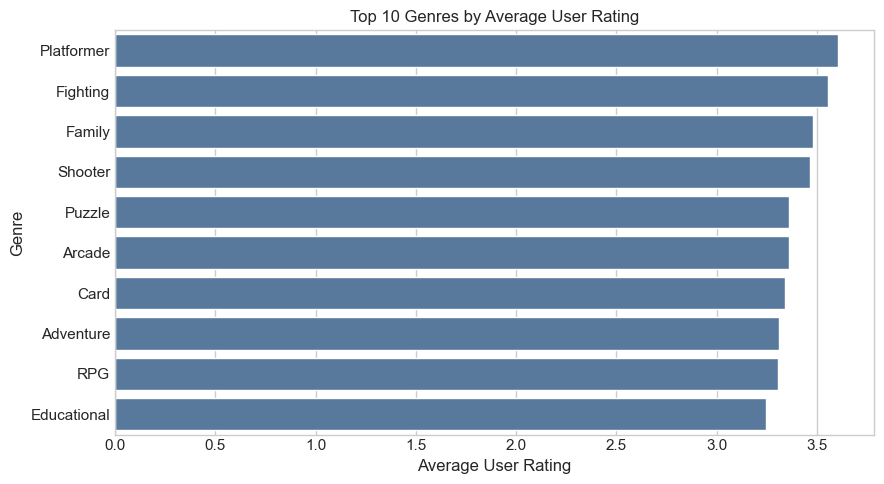

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/09_top_genres_by_avg_user_rating.png


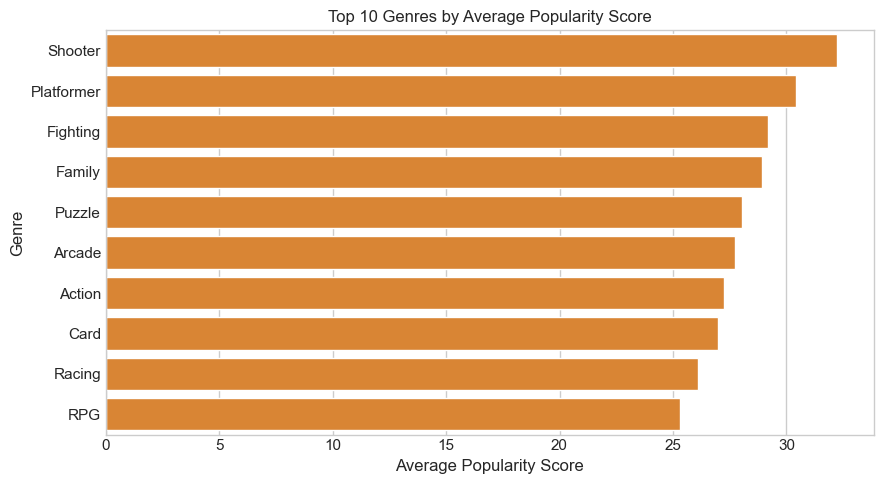

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/10_top_genres_by_avg_popularity.png


In [4]:
def to_numeric_if_exists(data, columns):
    """将存在的字段转换为数值型，无法转换的值设为缺失。"""
    for col in columns:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")
    return data


def save_current_figure(filename):
    """保存当前图表到 figures 目录，并在 Notebook 中展示。"""
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {output_path}")

metric_cols = ["user_rating", "metacritic", "popularity_score", "engagement_score"]
df_features = to_numeric_if_exists(df_features, metric_cols)

genre_stats = pd.DataFrame()
if not genre_long.empty:
    existing_metric_cols = [col for col in metric_cols if col in df_features.columns]
    genre_metrics = genre_long.merge(
        df_features[existing_metric_cols],
        left_on="row_index",
        right_index=True,
        how="left",
    )
    genre_stats = (
        genre_metrics
        .groupby("label")
        .agg(
            game_count=("row_index", "nunique"),
            avg_user_rating=("user_rating", "mean") if "user_rating" in existing_metric_cols else ("row_index", "size"),
            median_user_rating=("user_rating", "median") if "user_rating" in existing_metric_cols else ("row_index", "size"),
            avg_metacritic=("metacritic", "mean") if "metacritic" in existing_metric_cols else ("row_index", "size"),
            avg_popularity_score=("popularity_score", "mean") if "popularity_score" in existing_metric_cols else ("row_index", "size"),
            avg_engagement_score=("engagement_score", "mean") if "engagement_score" in existing_metric_cols else ("row_index", "size"),
        )
        .reset_index()
        .rename(columns={"label": "genre"})
    )
    genre_stats_filtered = genre_stats.query("game_count >= 30").copy()

    print("按平均用户评分排名前 10 的游戏类型：")
    top_genre_rating = genre_stats_filtered.sort_values("avg_user_rating", ascending=False).head(10)
    display(top_genre_rating.round(3))

    print("按平均热度分数排名前 10 的游戏类型：")
    top_genre_popularity = genre_stats_filtered.sort_values("avg_popularity_score", ascending=False).head(10)
    display(top_genre_popularity.round(3))

    if "avg_user_rating" in genre_stats_filtered.columns and not top_genre_rating.empty:
        plt.figure(figsize=(9, 5))
        sns.barplot(data=top_genre_rating, x="avg_user_rating", y="genre", color="#4C78A8")
        plt.title("Top 10 Genres by Average User Rating")
        plt.xlabel("Average User Rating")
        plt.ylabel("Genre")
        save_current_figure("09_top_genres_by_avg_user_rating.png")

    if "avg_popularity_score" in genre_stats_filtered.columns and not top_genre_popularity.empty:
        plt.figure(figsize=(9, 5))
        sns.barplot(data=top_genre_popularity, x="avg_popularity_score", y="genre", color="#F58518")
        plt.title("Top 10 Genres by Average Popularity Score")
        plt.xlabel("Average Popularity Score")
        plt.ylabel("Genre")
        save_current_figure("10_top_genres_by_avg_popularity.png")
else:
    print("无法进行类型与评分分析：all_genres 字段不存在或拆分结果为空。")

从输出表格和图表可以观察哪些游戏类型的平均用户评分更高，哪些类型的平均热度更高。解释这些结果时需要注意样本数量：即使已经过滤了少于 30 个样本的类型，样本量更大的类型通常仍然更稳定，小样本类型的排名更容易受到个别游戏影响。

## 4. 平台与多平台游戏分析

本节分析平台数量、多平台属性与评分、热度、玩家参与度之间的关系。这个部分对应课程中“从表格数据中提取信息”的思路，即通过已有字段和衍生字段发现规律。

如果 `is_multi_platform` 不存在，Notebook 会根据重新计算的 `platform_count_check` 构造多平台标记。

user_rating              metacritic               \
                       mean median count       mean median count   
platform_type                                                      
Multi-platform        3.328   3.44  8842     71.798   71.1  8565   
Single-platform       3.193   3.40  5771     69.054   68.8  5549   

                avg_playtime_hours              popularity_score               \
                              mean median count             mean median count   
platform_type                                                                   
Multi-platform               4.089    3.0  9005           27.269  28.14  9005   
Single-platform              3.158    2.0  5995           21.426  23.14  5995   

                engagement_score               
                            mean median count  
platform_type                                  
Multi-platform             4.395   2.25  9005  
Single-platform            2.942   0.91  5995

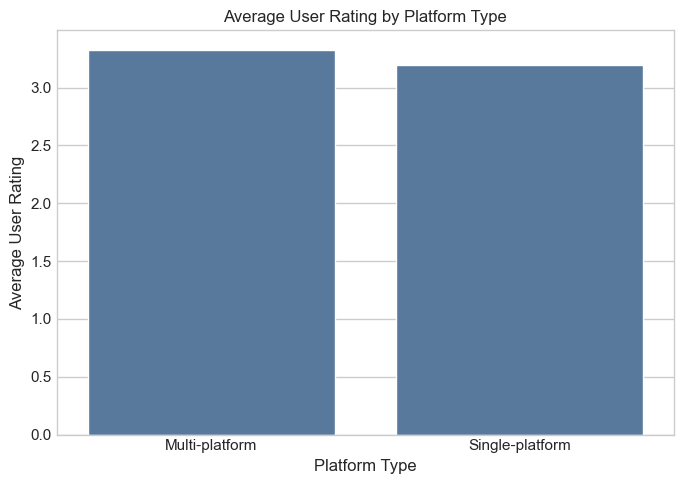

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/11_platform_type_avg_user_rating.png


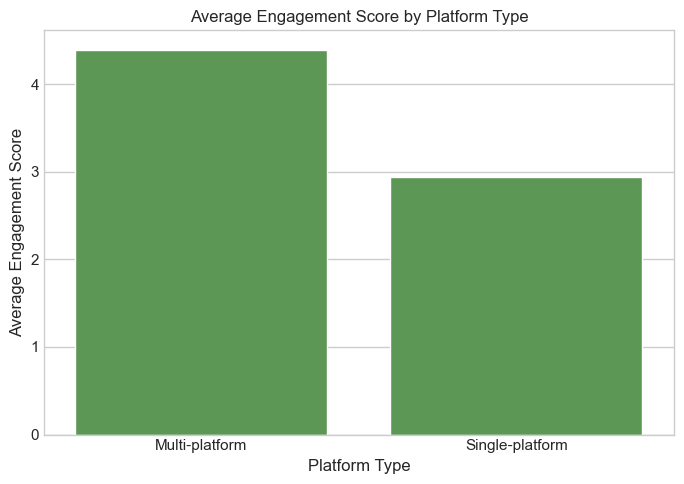

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/12_platform_type_avg_engagement.png


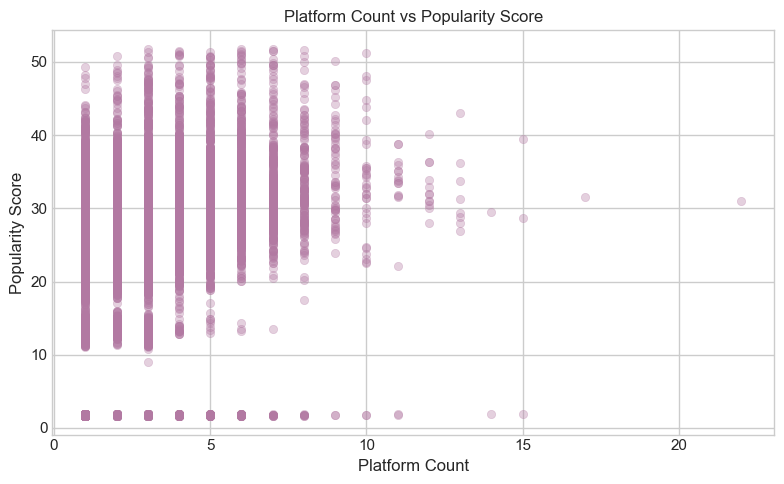

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/13_platform_count_vs_popularity.png


In [5]:
# 根据 all_platforms 重新计算平台数量，作为对原始 platform_count 的检查和补充
if "all_platforms" in df_features.columns:
    if not platform_long.empty:
        platform_count_check = platform_long.groupby("row_index")["label"].nunique()
        df_features["platform_count_check"] = df_features.index.to_series().map(platform_count_check).fillna(0).astype(int)
    else:
        df_features["platform_count_check"] = 0
else:
    print("提示：all_platforms 不存在，无法重新计算 platform_count_check。")

if "platform_count_check" in df_features.columns:
    if "is_multi_platform" not in df_features.columns:
        df_features["is_multi_platform_check"] = df_features["platform_count_check"] > 1
    else:
        is_multi_numeric = pd.to_numeric(df_features["is_multi_platform"], errors="coerce")
        df_features["is_multi_platform_check"] = np.where(
            is_multi_numeric.notna(),
            is_multi_numeric.astype(float) > 0,
            df_features["platform_count_check"] > 1,
        )
    df_features["platform_type"] = np.where(df_features["is_multi_platform_check"], "Multi-platform", "Single-platform")
else:
    df_features["platform_type"] = pd.NA

platform_metrics = ["user_rating", "metacritic", "avg_playtime_hours", "popularity_score", "engagement_score"]
df_features = to_numeric_if_exists(df_features, platform_metrics + ["platform_count", "platform_count_check"])
existing_platform_metrics = [col for col in platform_metrics if col in df_features.columns]

if existing_platform_metrics and "platform_type" in df_features.columns:
    platform_summary = (
        df_features
        .dropna(subset=["platform_type"])
        .groupby("platform_type")[existing_platform_metrics]
        .agg(["mean", "median", "count"])
        .round(3)
    )
    display(platform_summary)
else:
    platform_summary = pd.DataFrame()
    print("无法生成平台对比汇总表：缺少平台类型或指标字段。")

if {"platform_type", "user_rating"}.issubset(df_features.columns):
    plot_data = df_features.dropna(subset=["platform_type", "user_rating"])
    if not plot_data.empty:
        rating_mean = plot_data.groupby("platform_type", as_index=False)["user_rating"].mean()
        plt.figure(figsize=(7, 5))
        sns.barplot(data=rating_mean, x="platform_type", y="user_rating", color="#4C78A8")
        plt.title("Average User Rating by Platform Type")
        plt.xlabel("Platform Type")
        plt.ylabel("Average User Rating")
        save_current_figure("11_platform_type_avg_user_rating.png")

if {"platform_type", "engagement_score"}.issubset(df_features.columns):
    plot_data = df_features.dropna(subset=["platform_type", "engagement_score"])
    if not plot_data.empty:
        engagement_mean = plot_data.groupby("platform_type", as_index=False)["engagement_score"].mean()
        plt.figure(figsize=(7, 5))
        sns.barplot(data=engagement_mean, x="platform_type", y="engagement_score", color="#54A24B")
        plt.title("Average Engagement Score by Platform Type")
        plt.xlabel("Platform Type")
        plt.ylabel("Average Engagement Score")
        save_current_figure("12_platform_type_avg_engagement.png")

if {"platform_count_check", "popularity_score"}.issubset(df_features.columns):
    scatter_data = df_features[["platform_count_check", "popularity_score"]].dropna().copy()
    if not scatter_data.empty:
        # 绘图时截断 99% 分位数以上的热度值，避免极端值压缩主体区域
        upper = scatter_data["popularity_score"].quantile(0.99)
        scatter_data = scatter_data.query("popularity_score <= @upper")
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=scatter_data, x="platform_count_check", y="popularity_score", alpha=0.35, edgecolor=None, color="#B279A2")
        plt.title("Platform Count vs Popularity Score")
        plt.xlabel("Platform Count")
        plt.ylabel("Popularity Score")
        save_current_figure("13_platform_count_vs_popularity.png")

平台对比结果可以用来观察多平台游戏是否在评分、热度或参与度上表现更高。需要特别注意的是，这些差异只能说明变量之间存在统计相关或描述性差异，不能直接说明“多平台发行导致评分更高”或“平台数量导致参与度更高”。

## 5. 发行年份与年代趋势分析

本节从时间维度观察游戏发行趋势。虽然本项目不是严格的时间序列预测，但 `release_year` 可以帮助我们理解不同时代游戏数量、评分和类型分布的变化。

这里会去除明显异常年份，例如小于 1970 或大于当前年份太多的记录，然后分析每年和每个年代的游戏数量。

每年游戏发行数量：


,release_year,game_count
33,2012,480
34,2013,577
35,2014,999
36,2015,1316
37,2016,1595
38,2017,1218
39,2018,975
40,2019,725
41,2020,928
42,2021,1049


每个年代游戏数量：


,release_decade,game_count
0,1970s,2
1,1980s,69
2,1990s,468
3,2000s,1437
4,2010s,8571
5,2020s,4453


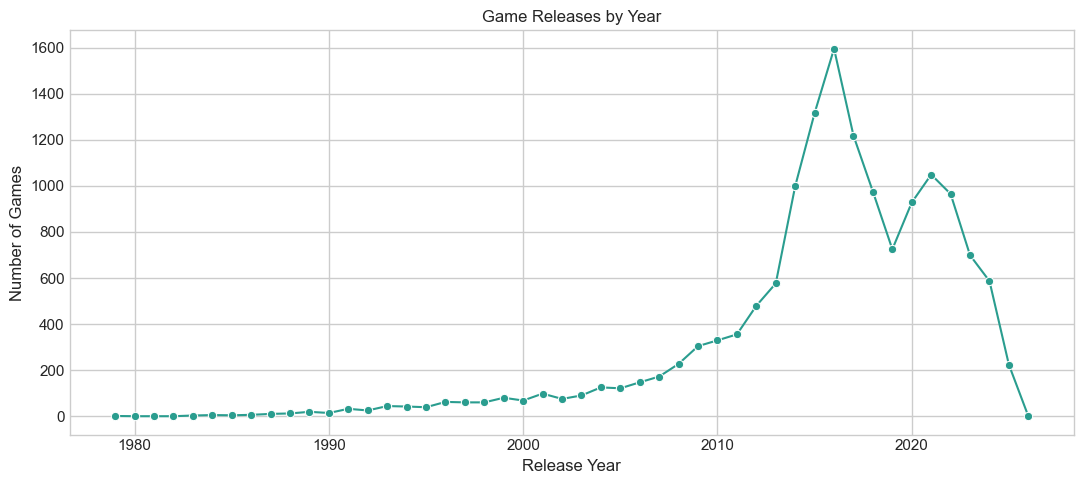

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/14_game_releases_by_year_deeper.png


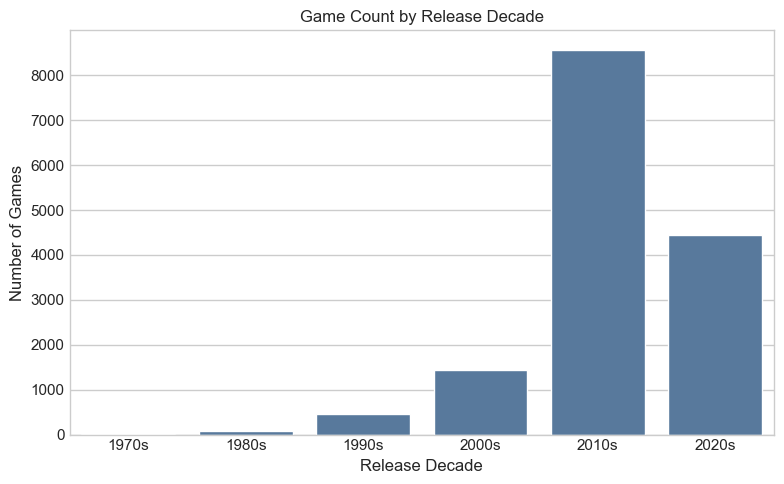

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/15_game_count_by_decade_deeper.png


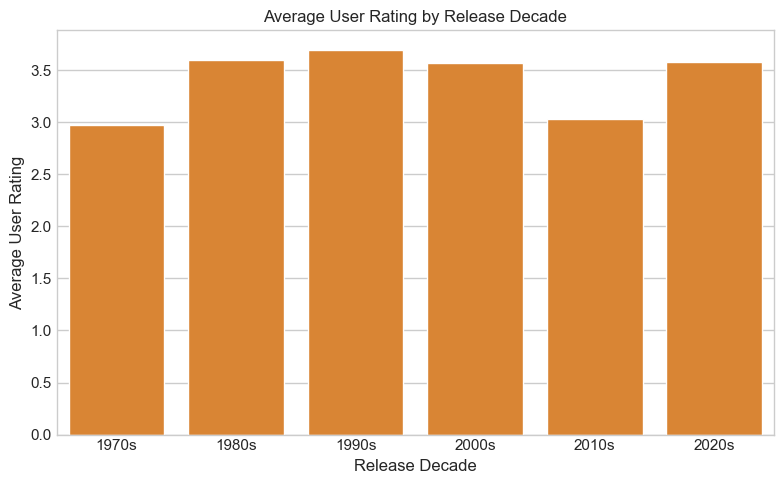

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/16_avg_user_rating_by_decade.png


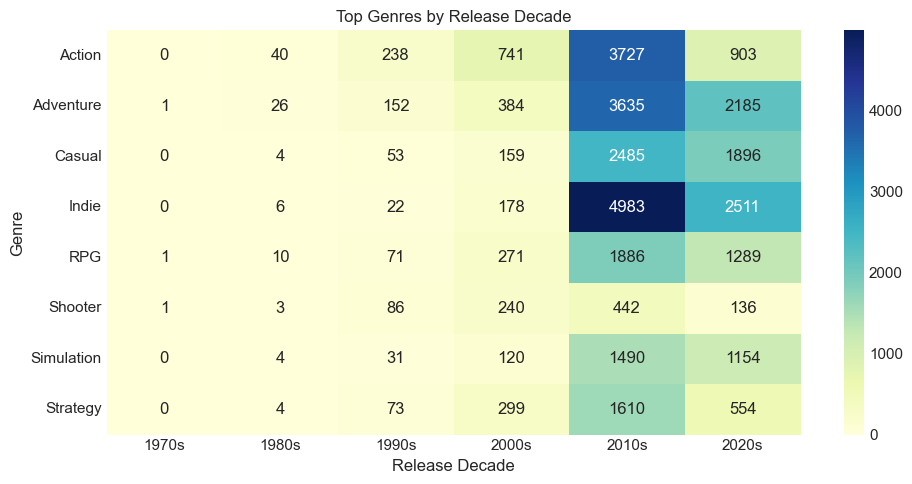

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/17_top_genres_by_decade_heatmap.png


In [6]:
current_year = pd.Timestamp.today().year

if "release_year" in df_features.columns:
    df_features["release_year_num"] = pd.to_numeric(df_features["release_year"], errors="coerce")
elif "release_date" in df_features.columns:
    df_features["release_year_num"] = pd.to_datetime(df_features["release_date"], errors="coerce").dt.year
else:
    df_features["release_year_num"] = np.nan
    print("提示：release_year 和 release_date 都不存在，无法进行年份趋势分析。")

valid_year_mask = df_features["release_year_num"].between(1970, current_year + 1)
time_df = df_features.loc[valid_year_mask].copy()
time_df["release_year_num"] = time_df["release_year_num"].astype(int)

def make_decade(year):
    if pd.isna(year):
        return pd.NA
    return f"{(int(year) // 10) * 10}s"

if "release_decade" not in df_features.columns:
    df_features["release_decade"] = df_features["release_year_num"].apply(make_decade)

time_df["release_decade"] = time_df["release_year_num"].apply(make_decade)

yearly_counts = time_df["release_year_num"].value_counts().sort_index()
decade_counts = time_df["release_decade"].value_counts().sort_index()

print("每年游戏发行数量：")
display(yearly_counts.rename_axis("release_year").reset_index(name="game_count").tail(15))
print("每个年代游戏数量：")
display(decade_counts.rename_axis("release_decade").reset_index(name="game_count"))

if not yearly_counts.empty:
    plt.figure(figsize=(11, 5))
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker="o", color="#2A9D8F")
    plt.title("Game Releases by Year")
    plt.xlabel("Release Year")
    plt.ylabel("Number of Games")
    save_current_figure("14_game_releases_by_year_deeper.png")

if not decade_counts.empty:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=decade_counts.index, y=decade_counts.values, color="#4C78A8")
    plt.title("Game Count by Release Decade")
    plt.xlabel("Release Decade")
    plt.ylabel("Number of Games")
    save_current_figure("15_game_count_by_decade_deeper.png")

if {"release_decade", "user_rating"}.issubset(time_df.columns):
    decade_rating = time_df.groupby("release_decade", as_index=False)["user_rating"].mean().dropna()
    if not decade_rating.empty:
        plt.figure(figsize=(8, 5))
        sns.barplot(data=decade_rating, x="release_decade", y="user_rating", color="#F58518")
        plt.title("Average User Rating by Release Decade")
        plt.xlabel("Release Decade")
        plt.ylabel("Average User Rating")
        save_current_figure("16_avg_user_rating_by_decade.png")

if not genre_long.empty and "release_decade" in time_df.columns:
    top8_genres = genre_long["label"].value_counts().head(8).index.tolist()
    genre_time = genre_long.merge(
        time_df[["release_decade"]],
        left_on="row_index",
        right_index=True,
        how="inner",
    )
    genre_time = genre_time[genre_time["label"].isin(top8_genres)]
    heatmap_data = pd.crosstab(genre_time["label"], genre_time["release_decade"])
    if not heatmap_data.empty:
        plt.figure(figsize=(10, 5))
        sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
        plt.title("Top Genres by Release Decade")
        plt.xlabel("Release Decade")
        plt.ylabel("Genre")
        save_current_figure("17_top_genres_by_decade_heatmap.png")

时间趋势图可以帮助我们观察游戏发行数量在哪些年份或年代更集中，也能初步比较不同年代的平均评分是否有变化。类型年代热力图则可以观察某些类型是否更集中出现在特定年代，但这种结果也可能受到数据集收录范围的影响。

## 6. 标签数量与描述文本长度分析

本节对 `all_tags` 和 `description_clean` 进行轻量级文本特征工程。这里不做复杂 NLP，只提取标签数量、描述文本长度等简单特征，用于观察文本信息与评分、热度之间是否存在关系。

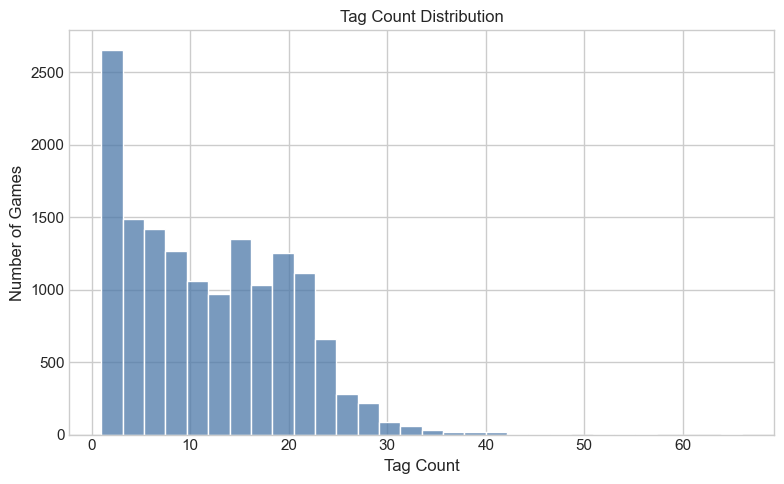

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/18_tag_count_distribution.png


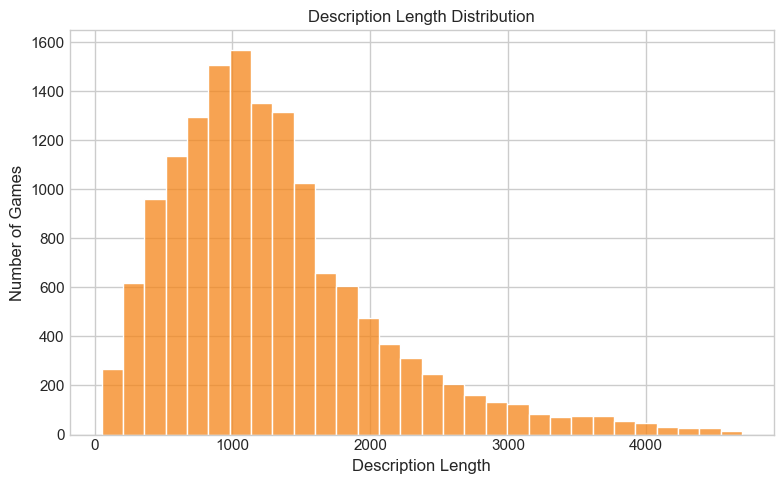

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/19_description_length_distribution.png


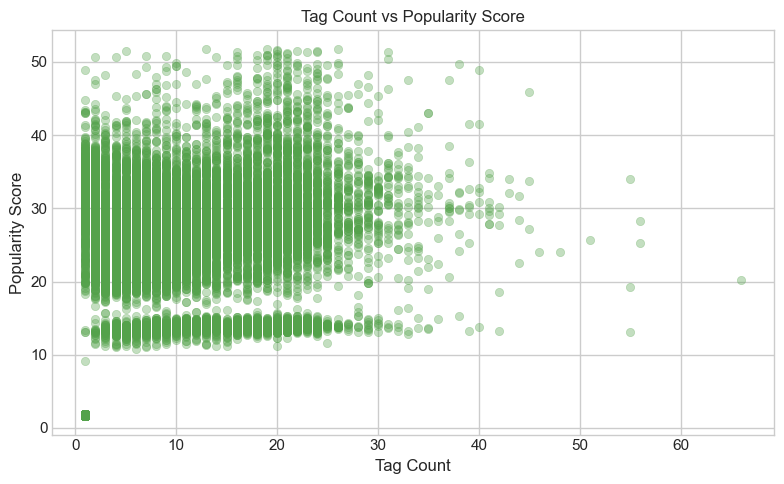

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/20_tag_count_vs_popularity.png


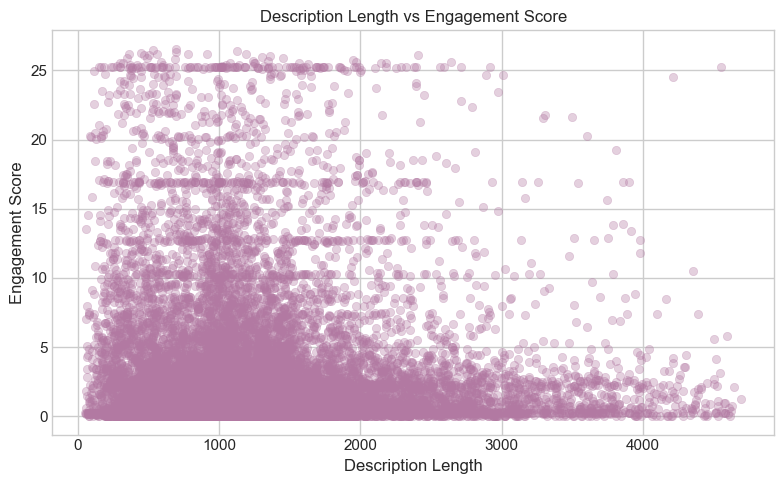

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/21_description_length_vs_engagement.png
标签数量、描述长度与评分/热度/参与度的相关系数：


,tag_count,description_length,user_rating,popularity_score,engagement_score
tag_count,1.000,0.120,0.184,0.281,0.012
description_length,0.120,1.000,-0.031,-0.020,-0.074
user_rating,0.184,-0.031,1.000,0.305,0.368
popularity_score,0.281,-0.020,0.305,1.000,0.438
engagement_score,0.012,-0.074,0.368,0.438,1.000


In [7]:
if "tag_count" not in df_features.columns:
    if not tag_long.empty:
        tag_count = tag_long.groupby("row_index")["label"].nunique()
        df_features["tag_count"] = df_features.index.to_series().map(tag_count).fillna(0).astype(int)
    else:
        df_features["tag_count"] = np.nan
        print("提示：all_tags 不存在或为空，无法构造 tag_count。")

if "description_length" not in df_features.columns:
    if "description_clean" in df_features.columns:
        df_features["description_length"] = df_features["description_clean"].fillna("").astype(str).str.len()
    else:
        df_features["description_length"] = np.nan
        print("提示：description_clean 不存在，无法构造 description_length。")

df_features = to_numeric_if_exists(df_features, ["tag_count", "description_length", "user_rating", "popularity_score", "engagement_score"])

if "tag_count" in df_features.columns and df_features["tag_count"].notna().any():
    plt.figure(figsize=(8, 5))
    sns.histplot(df_features["tag_count"].dropna(), bins=30, color="#4C78A8")
    plt.title("Tag Count Distribution")
    plt.xlabel("Tag Count")
    plt.ylabel("Number of Games")
    save_current_figure("18_tag_count_distribution.png")

if "description_length" in df_features.columns and df_features["description_length"].notna().any():
    desc_plot = df_features["description_length"].dropna()
    upper = desc_plot.quantile(0.99)
    plt.figure(figsize=(8, 5))
    sns.histplot(desc_plot[desc_plot <= upper], bins=30, color="#F58518")
    plt.title("Description Length Distribution")
    plt.xlabel("Description Length")
    plt.ylabel("Number of Games")
    save_current_figure("19_description_length_distribution.png")

if {"tag_count", "popularity_score"}.issubset(df_features.columns):
    plot_data = df_features[["tag_count", "popularity_score"]].dropna().copy()
    if not plot_data.empty:
        upper = plot_data["popularity_score"].quantile(0.99)
        plot_data = plot_data.query("popularity_score <= @upper")
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=plot_data, x="tag_count", y="popularity_score", alpha=0.35, edgecolor=None, color="#54A24B")
        plt.title("Tag Count vs Popularity Score")
        plt.xlabel("Tag Count")
        plt.ylabel("Popularity Score")
        save_current_figure("20_tag_count_vs_popularity.png")

if {"description_length", "engagement_score"}.issubset(df_features.columns):
    plot_data = df_features[["description_length", "engagement_score"]].dropna().copy()
    if not plot_data.empty:
        desc_upper = plot_data["description_length"].quantile(0.99)
        engage_upper = plot_data["engagement_score"].quantile(0.99)
        plot_data = plot_data.query("description_length <= @desc_upper and engagement_score <= @engage_upper")
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=plot_data, x="description_length", y="engagement_score", alpha=0.35, edgecolor=None, color="#B279A2")
        plt.title("Description Length vs Engagement Score")
        plt.xlabel("Description Length")
        plt.ylabel("Engagement Score")
        save_current_figure("21_description_length_vs_engagement.png")

corr_cols = ["tag_count", "description_length", "user_rating", "popularity_score", "engagement_score"]
existing_corr_cols = [col for col in corr_cols if col in df_features.columns]
text_feature_corr = df_features[existing_corr_cols].corr(numeric_only=True).round(3) if len(existing_corr_cols) >= 2 else pd.DataFrame()
print("标签数量、描述长度与评分/热度/参与度的相关系数：")
display(text_feature_corr)

标签数量和描述文本长度可以作为轻量级文本衍生特征。若散点图和相关系数显示正相关，只能说明这些变量之间存在初步联系，不能直接说明标签更多或描述更长会导致游戏更热门或参与度更高。

## 7. 综合相关性分析

本节将前面构造出的数值特征放在一起，观察它们与评分、热度、参与度之间的线性相关关系。

相关系数矩阵可以帮助我们快速发现可能值得继续研究的变量组合，但它只能反映线性关系，不能代表因果关系，也不能捕捉复杂的非线性模式。

用于相关性分析的字段：
['release_year',
 'release_year_num',
 'genre_count',
 'platform_count',
 'platform_count_check',
 'tag_count',
 'description_length',
 'user_rating',
 'metacritic',
 'avg_playtime_hours',
 'achievements_count',
 'popularity_score',
 'engagement_score',
 'ratings_count',
 'reviews_count',
 'library_count']


,release_year,release_year_num,genre_count,platform_count,platform_count_check,tag_count,description_length,user_rating,metacritic,avg_playtime_hours,achievements_count,popularity_score,engagement_score,ratings_count,reviews_count,library_count
release_year,1.000,1.000,0.094,-0.203,-0.203,0.332,0.073,0.012,-0.083,-0.004,0.016,-0.197,-0.183,-0.146,-0.146,-0.174
release_year_num,1.000,1.000,0.094,-0.203,-0.203,0.332,0.073,0.012,-0.083,-0.004,0.016,-0.197,-0.183,-0.146,-0.146,-0.174
genre_count,0.094,0.094,1.000,0.154,0.154,0.174,0.058,-0.166,-0.090,-0.029,0.031,-0.018,-0.126,-0.045,-0.045,0.008
platform_count,-0.203,-0.203,0.154,1.000,1.000,0.115,-0.029,0.163,0.202,0.055,0.128,0.338,0.167,0.285,0.286,0.326
platform_count_check,-0.203,-0.203,0.154,1.000,1.000,0.115,-0.029,0.163,0.202,0.055,0.128,0.338,0.167,0.285,0.286,0.326
tag_count,0.332,0.332,0.174,0.115,0.115,1.000,0.120,0.184,0.101,0.050,0.055,0.281,0.012,0.151,0.159,0.214
description_length,0.073,0.073,0.058,-0.029,-0.029,0.120,1.000,-0.031,-0.041,0.016,-0.022,-0.020,-0.074,-0.048,-0.045,-0.031
user_rating,0.012,0.012,-0.166,0.163,0.163,0.184,-0.031,1.000,0.655,0.138,0.007,0.305,0.368,0.255,0.254,0.159
metacritic,-0.083,-0.083,-0.090,0.202,0.202,0.101,-0.041,0.655,1.000,0.171,0.044,0.602,0.357,0.381,0.380,0.361
avg_playtime_hours,-0.004,-0.004,-0.029,0.055,0.055,0.050,0.016,0.138,0.171,1.000,0.042,0.192,0.289,0.168,0.170,0.118


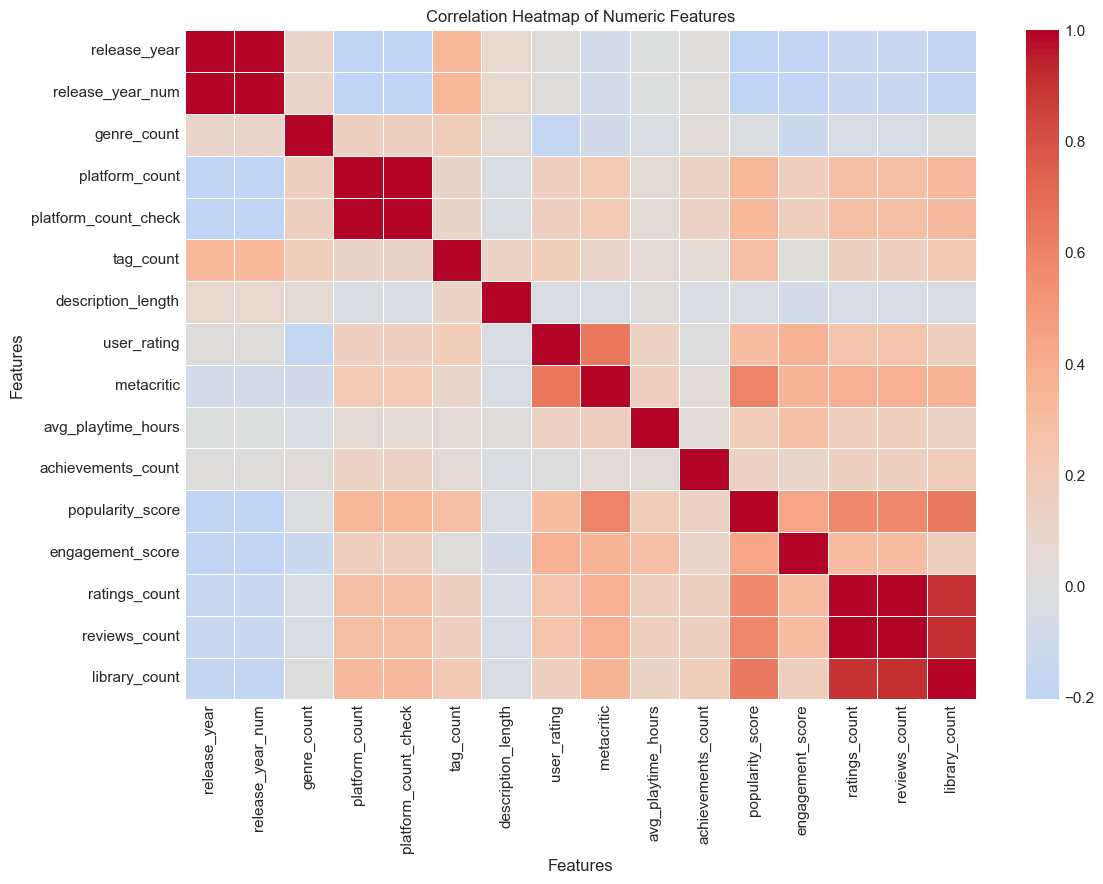

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/22_numeric_feature_correlation_heatmap.png
与 popularity_score 相关性最高的前 10 个特征：


,feature,abs_correlation
0,library_count,0.634
1,metacritic,0.602
2,reviews_count,0.582
3,ratings_count,0.574
4,engagement_score,0.438
5,platform_count,0.338
6,platform_count_check,0.338
7,user_rating,0.305
8,tag_count,0.281
9,release_year,0.197


与 engagement_score 相关性最高的前 10 个特征：


,feature,abs_correlation
0,popularity_score,0.438
1,user_rating,0.368
2,metacritic,0.357
3,ratings_count,0.310
4,reviews_count,0.310
5,avg_playtime_hours,0.289
6,release_year,0.183
7,release_year_num,0.183
8,library_count,0.171
9,platform_count,0.167


In [8]:
# 如果 genre_count 尚不存在，则根据 genre_long 构造
if "genre_count" not in df_features.columns:
    if not genre_long.empty:
        genre_count = genre_long.groupby("row_index")["label"].nunique()
        df_features["genre_count"] = df_features.index.to_series().map(genre_count).fillna(0).astype(int)
    else:
        df_features["genre_count"] = np.nan

candidate_numeric_cols = [
    "release_year", "release_year_num", "genre_count", "platform_count", "platform_count_check",
    "tag_count", "description_length", "user_rating", "metacritic", "avg_playtime_hours",
    "achievements_count", "popularity_score", "engagement_score", "ratings_count",
    "reviews_count", "library_count",
]
existing_numeric_cols = [col for col in candidate_numeric_cols if col in df_features.columns]

corr_data = df_features[existing_numeric_cols].copy()
for col in corr_data.columns:
    corr_data[col] = pd.to_numeric(corr_data[col], errors="coerce")

corr_matrix = corr_data.corr(numeric_only=True).round(3)
print("用于相关性分析的字段：")
pprint(existing_numeric_cols)

display(corr_matrix)

if not corr_matrix.empty:
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.5)
    plt.title("Correlation Heatmap of Numeric Features")
    plt.xlabel("Features")
    plt.ylabel("Features")
    save_current_figure("22_numeric_feature_correlation_heatmap.png")

if "popularity_score" in corr_matrix.columns:
    top_popularity_corr = (
        corr_matrix["popularity_score"]
        .drop(labels=["popularity_score"], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .rename("abs_correlation")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    print("与 popularity_score 相关性最高的前 10 个特征：")
    display(top_popularity_corr)
else:
    top_popularity_corr = pd.DataFrame()
    print("缺少 popularity_score，无法输出相关性排名。")

if "engagement_score" in corr_matrix.columns:
    top_engagement_corr = (
        corr_matrix["engagement_score"]
        .drop(labels=["engagement_score"], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .rename("abs_correlation")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    print("与 engagement_score 相关性最高的前 10 个特征：")
    display(top_engagement_corr)
else:
    top_engagement_corr = pd.DataFrame()
    print("缺少 engagement_score，无法输出相关性排名。")

相关性热力图可以帮助我们观察哪些特征与热度、参与度、评分之间关系更明显。如果后续课程项目需要进一步扩展，可以基于这些特征继续做 PCA、聚类、评分预测或简单推荐实验。但在当前 Notebook 中，我们只做探索分析，不实现这些模型。

## 8. 保存深入分析后的数据

本节将新增特征后的数据保存到 `data/processed/` 目录，方便后续继续分析或写报告时复用。保存文件为 `data/processed/Ultimate_Games_Dataset_features.csv`。

In [9]:
FEATURES_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df_features.to_csv(FEATURES_DATA_PATH, index=False)

if FEATURES_DATA_PATH.exists():
    print(f"保存成功：{FEATURES_DATA_PATH}")
    print(f"保存数据维度：{df_features.shape[0]:,} 行 x {df_features.shape[1]:,} 列")
else:
    print("保存失败，请检查路径权限。")

保存成功：/Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/Ultimate_Games_Dataset_features.csv
保存数据维度：15,000 行 x 51 列


保存后的特征数据可以作为后续 Notebook 或课程报告分析的数据基础。它保留了原始字段，并增加了本 Notebook 中构造的辅助特征。

## 9. 初步洞察总结

基于本 Notebook 的统计表和图表，可以得到以下适合课程报告使用的初步洞察：

1. 数据集规模和主要字段：本次分析的数据集包含 15,000 款游戏，经过本 Notebook 的特征工程后共有 51 个字段。主要字段包括游戏名称、发行年份、游戏类型、平台、标签、用户评分、Metacritic 评分、平均游玩时长、热度分数和参与度分数等。

2. 游戏类型与评分/热度的关系：在过滤样本数少于 30 的类型后，平均用户评分较高的类型包括 Platformer、Fighting、Family、Shooter 和 Puzzle。其中 Shooter 的平均热度分数最高，Platformer、Fighting、Family 和 Puzzle 也位于热度排名前列。由于一款游戏可以属于多个类型，这里的结果反映的是多标签统计下的类型特征，而不是互斥分类结果。

3. 单平台与多平台游戏的差异：多平台游戏在多个指标上都高于单平台游戏。多平台游戏的平均用户评分约为 3.33，单平台游戏约为 3.19；多平台游戏的平均 Metacritic 评分约为 71.80，单平台游戏约为 69.05；多平台游戏的平均热度和参与度也更高。这说明多平台属性和更高的评分、热度、参与度之间存在一定相关关系，但不能直接解释为因果关系。

4. 发行年份和年代趋势：游戏数量主要集中在 2010s 和 2020s，其中 2010s 有 8,571 款游戏，2020s 有 4,453 款游戏。早期年代的数据量明显更少，说明数据集对近年游戏的覆盖更充分。平均用户评分在不同年代之间存在差异，例如 1990s 和 2020s 的平均评分相对较高，但这些差异可能受到样本数量和数据收录范围影响。

5. 标签数量、描述长度与热度/参与度的关系：`tag_count` 与 `popularity_score` 的相关系数约为 0.28，说明标签数量更多的游戏在热度上可能略高，但关系并不强。`description_length` 与 `engagement_score` 的相关系数约为 -0.07，几乎没有明显线性关系。因此，简单文本长度特征只能作为初步线索，不能单独解释游戏热度或参与度。

6. 综合相关性分析发现：与 `popularity_score` 相关性较高的特征包括 `library_count`、`metacritic`、`reviews_count`、`ratings_count` 和 `engagement_score`。与 `engagement_score` 相关性较高的特征包括 `popularity_score`、`user_rating`、`metacritic`、`ratings_count`、`reviews_count` 和 `avg_playtime_hours`。这些结果说明用户行为数量、评分指标和热度/参与度之间存在较明显联系。

7. 当前分析的局限性：本 Notebook 主要使用描述性统计、分组对比和相关性分析，不能证明因果关系。多标签字段会导致同一款游戏在多个类型中重复出现，因此类型统计需要谨慎解释。此外，评分和热度指标可能受到平台覆盖、发行时间、用户群体和数据来源机制的共同影响。

8. 后续可以继续做的方向：在后续课程项目中，可以基于当前特征继续尝试 PCA 降维、聚类分析、评分预测或简单推荐实验。不过这些方向属于进一步扩展，本 Notebook 暂不实现复杂模型或推荐系统。